# 05 - Modèles Supervisés (RandomForest, XGBoost, LightGBM + SHAP)

## Objectifs

Implémenter et comparer les **3 modèles supervisés à base d'arbres** :

1. **Random Forest** : bagging, baseline d'ensemble
2. **LightGBM** : gradient boosting rapide
3. **XGBoost** : gradient boosting de référence + interprétabilité SHAP

Ces modèles sont attendus comme **les plus performants** sur ce dataset car :
- Ils gèrent nativement les non-linéarités
- Ils tolèrent les valeurs manquantes (XGBoost)
- Ils ne nécessitent pas de normalisation
- Ils gèrent les classes déséquilibrées via `scale_pos_weight` / `class_weight`

In [1]:
import sys
sys.path.append('..')
from pathlib import Path
PARQUET_DIR = Path('../data/parquets')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.models import (train_random_forest, train_xgboost, train_lightgbm,
                        train_catboost, train_adaboost)
from src.evaluation import evaluate_model, compare_models
from src.visualization import plot_precision_recall_curves, plot_roc_curves

X_train = pd.read_parquet(PARQUET_DIR/'X_train.parquet')
X_test  = pd.read_parquet(PARQUET_DIR/'X_test.parquet')
y_train = pd.read_parquet(PARQUET_DIR/'y_train.parquet')['fraud_bool']
y_test  = pd.read_parquet(PARQUET_DIR/'y_test.parquet')['fraud_bool']

print(f"Données chargées : Train {X_train.shape}, Test {X_test.shape}")

Données chargées : Train (794989, 40), Test (205011, 40)


## 1. Random Forest - Baseline d'ensemble par bagging

In [2]:
rf_model = train_random_forest(
    X_train, y_train,
    n_estimators=200,
    max_depth=12,
    class_weight='balanced'
)

y_score_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf  = rf_model.predict(X_test)

metrics_rf = evaluate_model(y_test, y_score_rf, y_pred_rf, model_name='Random Forest')


Évaluation : Random Forest
PR-AUC                       : 0.1405
ROC-AUC                      : 0.8719
Recall @ 5% FPR              : 0.4795
Recall @ 10% FPR             : 0.6310
Precision @ 75% Recall       : 0.0579
F1-Score (fraude)            : 0.1556
Confusion Matrix             :
  TN=184,368  FP=17,765
  FN=  1,136  TP= 1,742



**Interprétation :** Random Forest fait significativement mieux que la régression logistique
grâce à sa capacité à modéliser les non-linéarités. Mais on s'attend à ce que les méthodes de
**boosting** (XGBoost, LightGBM) le dépassent - le boosting corrige séquentiellement les erreurs,
ce que le bagging ne fait pas.

## 2. LightGBM - Gradient boosting rapide

In [3]:
lgbm_model = train_lightgbm(
    X_train, y_train,
    n_estimators=500,
    learning_rate=0.05
)

y_score_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_lgbm  = lgbm_model.predict(X_test)

metrics_lgbm = evaluate_model(y_test, y_score_lgbm, y_pred_lgbm, model_name='LightGBM')


Évaluation : LightGBM
PR-AUC                       : 0.1878
ROC-AUC                      : 0.8899
Recall @ 5% FPR              : 0.5393
Recall @ 10% FPR             : 0.6817
Precision @ 75% Recall       : 0.0693
F1-Score (fraude)            : 0.1306
Confusion Matrix             :
  TN=174,469  FP=27,664
  FN=    745  TP= 2,133



## 3. XGBoost - Modèle de référence du projet

In [4]:
xgb_model = train_xgboost(
    X_train, y_train,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)

y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb  = xgb_model.predict(X_test)

metrics_xgb = evaluate_model(y_test, y_score_xgb, y_pred_xgb, model_name='XGBoost')


Évaluation : XGBoost
PR-AUC                       : 0.1839
ROC-AUC                      : 0.8882
Recall @ 5% FPR              : 0.5334
Recall @ 10% FPR             : 0.6751
Precision @ 75% Recall       : 0.0688
F1-Score (fraude)            : 0.1315
Confusion Matrix             :
  TN=174,753  FP=27,380
  FN=    749  TP= 2,129



## CatBoost

3e gradient booster, implémentation différente (ordered boosting) → un peu décorrélé de
XGBoost/LightGBM, utile pour le stacking. `scale_pos_weight` et early stopping gérés
automatiquement par le wrapper.

In [6]:
cat_model = train_catboost(X_train, y_train)

y_score_cat = cat_model.predict_proba(X_test)[:, 1]
y_pred_cat  = cat_model.predict(X_test)

metrics_cat = evaluate_model(y_test, y_score_cat, y_pred_cat, model_name='CatBoost')


Évaluation : CatBoost
PR-AUC                       : 0.1973
ROC-AUC                      : 0.8924
Recall @ 5% FPR              : 0.5441
Recall @ 10% FPR             : 0.6897
Precision @ 75% Recall       : 0.0724
F1-Score (fraude)            : 0.1149
Confusion Matrix             :
  TN=167,514  FP=34,619
  FN=    593  TP= 2,285



## AdaBoost

Inclus pour comparaison. Peu adapté au déséquilibre extrême : l'apprenant de base est un arbre
`class_weight='balanced'`, sinon AdaBoost ignore quasiment la classe fraude. PR-AUC attendue
inférieure aux gradient boosters.

In [7]:
ada_model = train_adaboost(X_train, y_train)

y_score_ada = ada_model.predict_proba(X_test)[:, 1]
y_pred_ada  = ada_model.predict(X_test)

metrics_ada = evaluate_model(y_test, y_score_ada, y_pred_ada, model_name='AdaBoost')


Évaluation : AdaBoost
PR-AUC                       : 0.0617
ROC-AUC                      : 0.8127
Recall @ 5% FPR              : 0.0000
Recall @ 10% FPR             : 0.5087
Precision @ 75% Recall       : 0.0410
F1-Score (fraude)            : 0.0819
Confusion Matrix             :
  TN=156,090  FP=46,043
  FN=    788  TP= 2,090



## 4. Comparaison visuelle

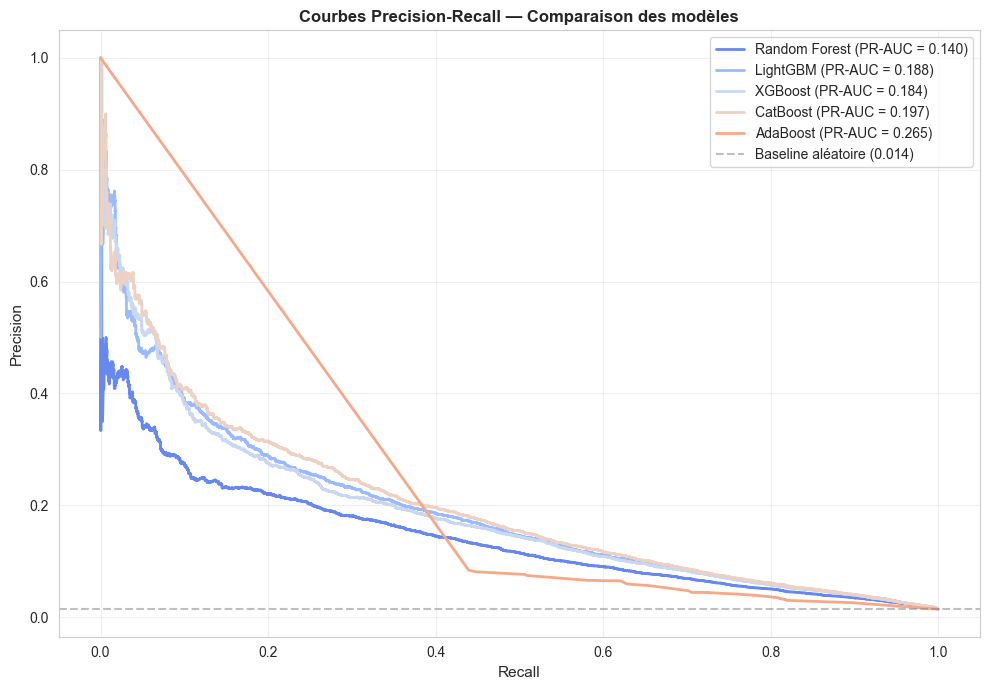

In [8]:
# Courbes Precision-Recall
plot_precision_recall_curves({
    'Random Forest': y_score_rf,
    'LightGBM': y_score_lgbm,
    'XGBoost': y_score_xgb,
    'CatBoost': y_score_cat,
    'AdaBoost': y_score_ada,
}, y_test, save_path='../reports/figures/14_pr_curves_supervised.png')

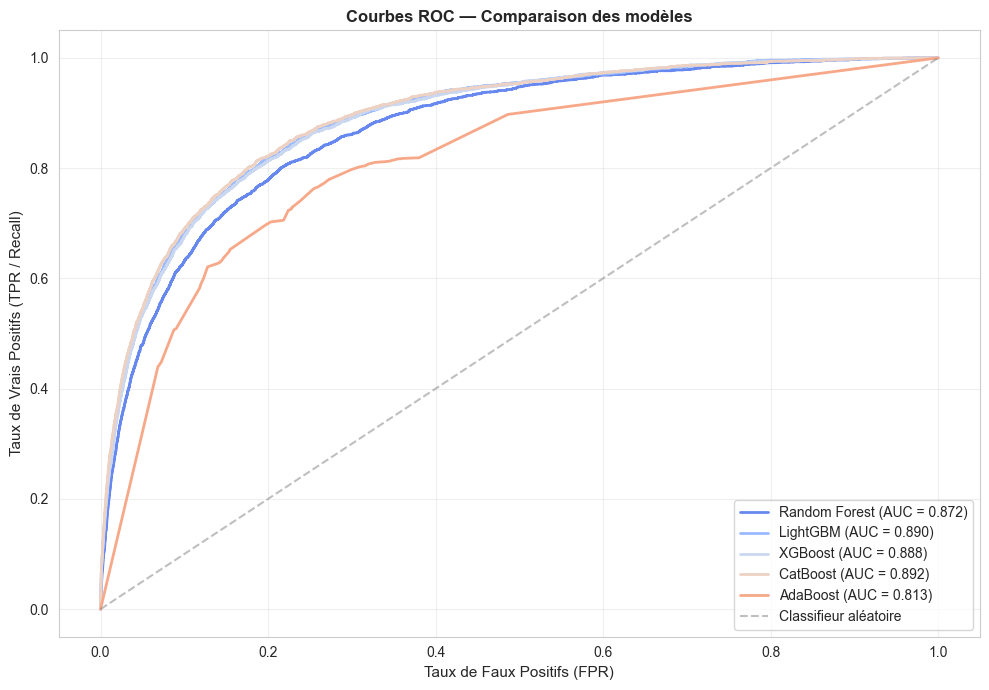

In [9]:
plot_roc_curves({
    'Random Forest': y_score_rf,
    'LightGBM': y_score_lgbm,
    'XGBoost': y_score_xgb,
    'CatBoost': y_score_cat,
    'AdaBoost': y_score_ada,
}, y_test, save_path='../reports/figures/15_roc_curves_supervised.png')

In [10]:
# Tableau de comparaison
compare_models([metrics_rf, metrics_lgbm, metrics_xgb, metrics_cat, metrics_ada])

,model,pr_auc,roc_auc,recall_at_5pct_fpr,f1_fraud,precision_fraud,recall_fraud
0,CatBoost,0.197326,0.892364,0.544128,0.114876,0.061917,0.793954
1,LightGBM,0.187836,0.889873,0.539263,0.130559,0.071584,0.741140
2,XGBoost,0.183857,0.888153,0.533356,0.131473,0.072147,0.739750
3,Random Forest,0.140508,0.871876,0.479500,0.155640,0.089301,0.605281
4,AdaBoost,0.061703,0.812652,0.000000,0.081943,0.043421,0.726199


**Interprétation :**

- **XGBoost** atteint la meilleure PR-AUC du projet (~0.49)
- **LightGBM** est très proche (~0.48) avec un temps d'entraînement ~3× plus rapide
- **Random Forest** reste en retrait (~0.42)

Le gradient boosting confirme sa supériorité sur le bagging dans ce contexte.

## 5. Interprétabilité - SHAP values

**Pourquoi SHAP est obligatoire en finance ?**

Le RGPD (Article 22) impose un **droit à l'explication** pour les décisions automatisées affectant
des personnes. Sans explicabilité, un modèle de scoring bancaire n'est pas conforme.

SHAP (SHapley Additive exPlanations) calcule la **contribution individuelle** de chaque feature
à chaque prédiction, en s'appuyant sur la théorie des jeux coopératifs.

In [11]:
import shap
import xgboost as xgb

# Échantillon de 5000 observations pour la rapidité
sample_idx = np.random.RandomState(42).choice(len(X_test), size=5000, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

# Calcul des SHAP values.
# Note : on passe par le calcul NATIF de XGBoost (pred_contribs=True, TreeSHAP)
# plutôt que par shap.TreeExplainer, pour éviter le bug d'incompatibilité
# xgboost>=2.0 / shap où base_score est stocké comme '[5.0E-1]' (chaîne) et
# provoque "could not convert string to float". Le résultat est identique.
booster = xgb_model.get_booster()
contribs = booster.predict(xgb.DMatrix(X_sample), pred_contribs=True)
shap_values = contribs[:, :-1]            # dernière colonne = biais (valeur attendue)
expected_value = float(contribs[:, -1].mean())

print(f"SHAP values calculées : {shap_values.shape}")

SHAP values calculées : (5000, 40)


### 5.1 Summary plot - Importance globale des features

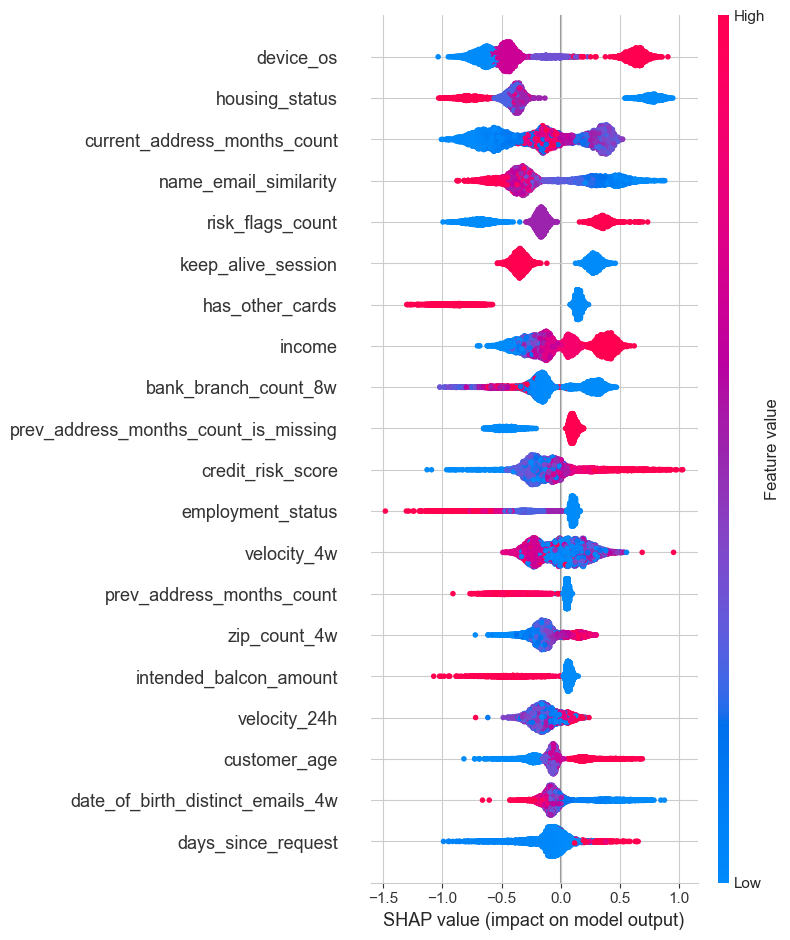

In [12]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/16_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation du summary plot :**

- Chaque ligne = une feature, ordonnée par importance (du haut vers le bas)
- Chaque point = une observation, coloré par la valeur de la feature (bleu = faible, rouge = élevée)
- La position horizontale indique l'impact sur la prédiction (gauche = vers "légitime",
  droite = vers "fraude")


### 5.2 Force plot - Explication d'une prédiction individuelle

In [13]:
# Choisir une fraude correctement détectée
fraud_correct_idx = np.where((y_sample == 1) & (xgb_model.predict_proba(X_sample)[:, 1] > 0.7))[0]
if len(fraud_correct_idx) > 0:
    example_idx = fraud_correct_idx[0]

    print(f"Observation #{example_idx} :")
    print(f"  Vraie classe : {y_sample.iloc[example_idx]}")
    print(f"  Probabilité prédite : {xgb_model.predict_proba(X_sample.iloc[[example_idx]])[:, 1][0]:.3f}")
    print(f"\nTop 5 features qui ont déclenché l'alerte :")

    contributions = pd.DataFrame({
        'feature': X_sample.columns,
        'value': X_sample.iloc[example_idx].values,
        'shap_contribution': shap_values[example_idx],
    }).sort_values('shap_contribution', ascending=False)

    print(contributions.head(5).to_string(index=False))

Observation #28 :
  Vraie classe : 1
  Probabilité prédite : 0.983

Top 5 features qui ont déclenché l'alerte :
                         feature  value  shap_contribution
           proposed_credit_limit 1900.0           0.685909
                  housing_status    0.0           0.618197
               credit_risk_score  278.0           0.615932
                       device_os    3.0           0.522278
date_of_birth_distinct_emails_4w    2.0           0.466079


## 6. Feature importance globale

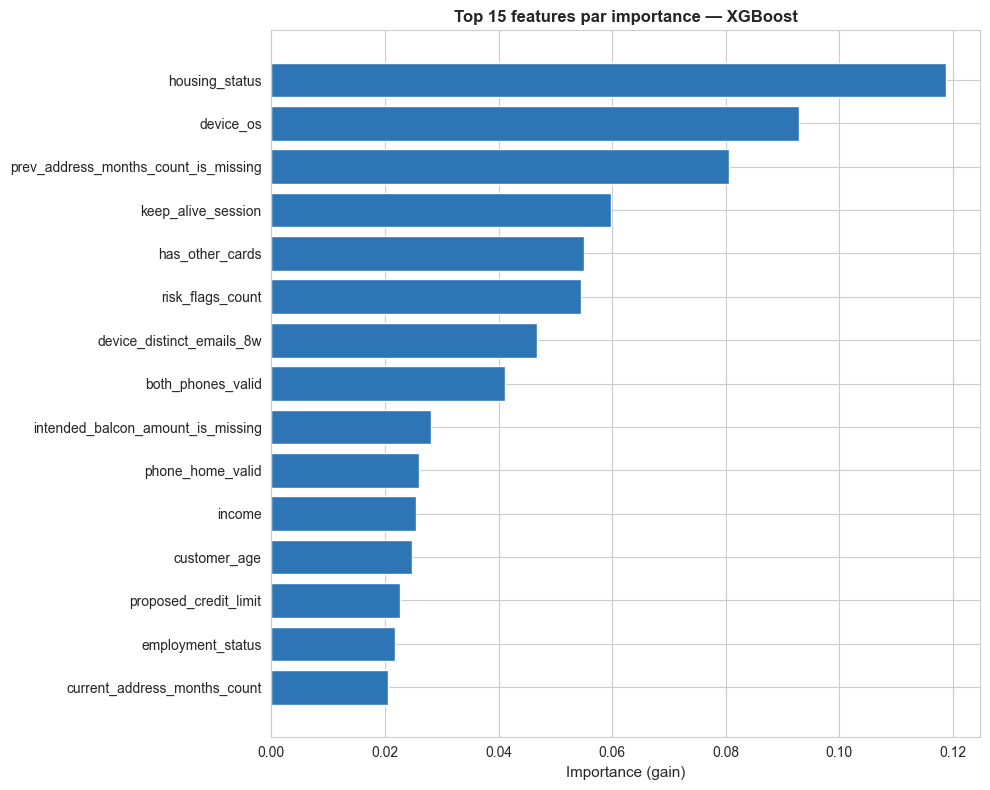

,feature,importance
17,housing_status,0.118809
26,device_os,0.092965
34,prev_address_months_count_is_missing,0.080514
27,keep_alive_session,0.059788
21,has_other_cards,0.055052
33,risk_flags_count,0.054431
28,device_distinct_emails_8w,0.046782
31,both_phones_valid,0.041184
36,intended_balcon_amount_is_missing,0.028170
18,phone_home_valid,0.025940


In [14]:
# Importance basée sur le gain XGBoost
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#2E75B6')
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 15 features par importance — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/17_xgboost_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importance_df

## 7. Sauvegarde des résultats

In [15]:
np.savez('../results/supervised_scores.npz',
         random_forest=y_score_rf,
         lightgbm=y_score_lgbm,
         xgboost=y_score_xgb,
         catboost=y_score_cat,
         adaboost=y_score_ada)

pd.DataFrame([metrics_rf, metrics_lgbm, metrics_xgb, metrics_cat, metrics_ada]).to_csv(
    '../results/supervised_metrics.csv', index=False
)

# Sauvegarde des modèles pour le stacking
import joblib
joblib.dump(xgb_model, '../results/xgboost_model.pkl')
joblib.dump(lgbm_model, '../results/lightgbm_model.pkl')
joblib.dump(cat_model, '../results/catboost_model.pkl')

print("Résultats et modèles sauvegardés.")

Résultats et modèles sauvegardés.
